# Modelos de regresión lineal

Los modelos de regresión lineal son aquellos que intentan encontrar una ecuación del tipo:
$$ y = f(X) $$
donde **X** son un conjunto de variables, o características, predictoras, y $y$ es la variable por predecir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Se va a trabajar con un dataset sintético con solo 2 variables, una de entrada, y otra de salida.

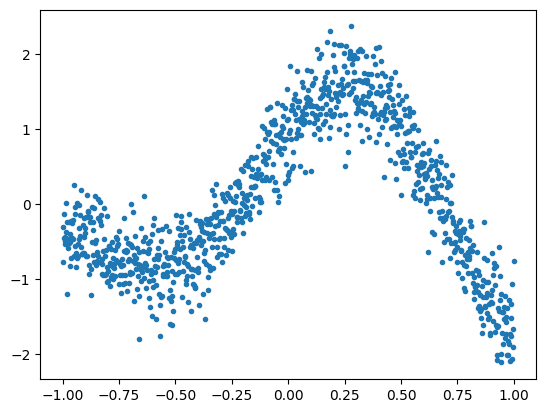

In [2]:
X = np.linspace(-1, 1, 1000)
ruido = np.random.normal(0, 0.333, 1000)
y = np.sin(4*X) + np.cos(3*X) + ruido
plt.plot(X,y, '.');

El modelo más simple que se puede construir es una línea recta de la forma:
$$ y = w_0 + w_{1}*x$$

Donde $w_0$ es el intercepto de la línea y $w_1$ es la pendiente de la línea.

Con un modelo de regresión lineal simple se pueden encontrar los mejores valores de estos parámetros.

In [3]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = X.reshape(-1,1)
model.fit(X,y)
model.score(X,y)

0.042712007580612

In [4]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'La pendiente del modelo es {model.coef_[0]:.3f}')

El intercepto del modelo es 0.057
La pendiente del modelo es 0.356


Si se compara lo que predice el modelo contra los datos reales, evidentemente el modelo es malísimo.

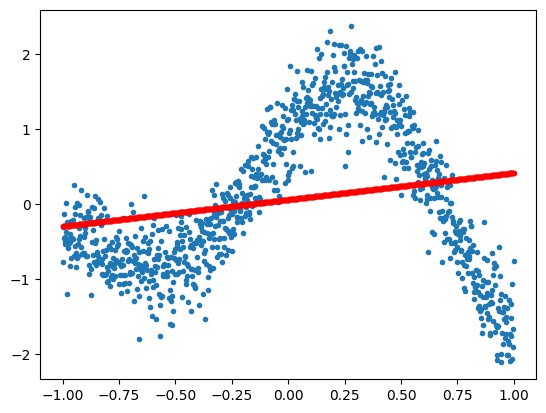

In [5]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X), 'r.');

Para poder **cuantificar** que tan bueno es un modelo es necesario usar una **métrica de evaluación**. El método `score` mide el modelo usando una métrica, que en este caso es el [coeficiente de determinación](https://es.wikipedia.org/wiki/Coeficiente_de_determinaci%C3%B3n) o $R^2$.

In [6]:
print(f'R^2 del modelo: {model.score(X,y):.3f}')

R^2 del modelo: 0.043


# Métricas de evaluación

Este resultado nos corrobora que este modelo es malísimo, porque mientras más cerca a 0 peor, y mientras más cerca a 1, mejor.

Sin embargo, es posible, y deseable, usar otras métricas. Scikit Learn tiene un buen conjunto de métricas implementadas (que puede consultar [aquí](https://scikit-learn.org/stable/modules/model_evaluation.html)).
Métricas de regresión muy utilizadas son el **MSE** ([Mean squared error](https://es.wikipedia.org/wiki/Error_cuadr%C3%A1tico_medio)), **RMSE** (Root mean squared error), el **MAE** ([Mean absolute error](https://es.wikipedia.org/wiki/Error_absoluto_medio)), y el [Median absolute error](https://scikit-learn.org/stable/modules/model_evaluation.html#median-absolute-error).

Es importante notar que las **métricas de evaluación** son funciones que tienen el propósito de evaluar el modelo, mientras que las **funciones de error** son las funciones que intenta optimizar el algoritmo de optimización que encuentra los parámetros del modelo. De esta manera, pueden ser funciones matemáticas diferentes (o las mismas también).

In [7]:
from sklearn.metrics import root_mean_squared_error, median_absolute_error

print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X)):.3f}')

RMSE del modelo: 0.973
MedAE del modelo: 0.709


# Extracción de características

Se podría intentar obtener un mejor modelo **añadiendo nuevas características** al modelo, en este caso, elevando la variable predictora a alguna potencia. Esto se llama un **modelo de regresión polinómica**.

Vamos a empezar con un modelo polinómico de grado 2, de la forma:
$$ y = w_0 + w_{1}*x + w_{2}*x^2$$

Aunque esto se podría hacer a mano en este caso simple, se va a usar el método `PolynomialFeatures` de Scikit Learn.


In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_p = poly.fit_transform(X)
X_p

array([[-1.        ,  1.        ],
       [-0.997998  ,  0.996     ],
       [-0.995996  ,  0.99200802],
       ...,
       [ 0.995996  ,  0.99200802],
       [ 0.997998  ,  0.996     ],
       [ 1.        ,  1.        ]])

In [9]:
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X_p)):.3f}')

R^2 del modelo: 0.477
RMSE del modelo: 0.719
MedAE del modelo: 0.578


Evidentemente el modelo mejora, aunque todavía es malo.

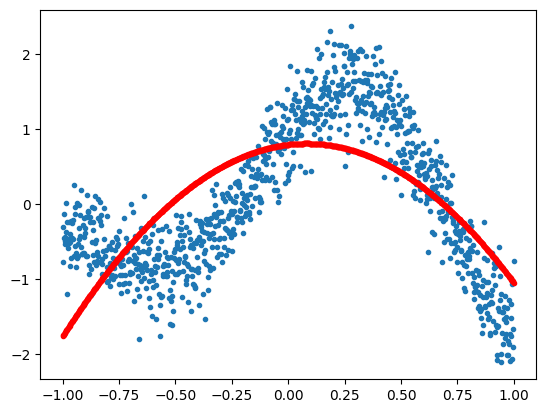

In [10]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.');

Este modelo ya tendría 3 parámetros: el intercepto, la pendiente del término lineal, y la pendiente del término cuadrático.

In [11]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'El coeficiente del término lineal del modelo es {model.coef_[0]:.3f}')
print(f'El coeficiente del término cuadrático del modelo es {model.coef_[1]:.3f}')

El intercepto del modelo es 0.790
El coeficiente del término lineal del modelo es 0.356
El coeficiente del término cuadrático del modelo es -2.195


Ahora, se va a probar con un modelo polinómico de grado 3.

---

Now, it is going to be tested with a polynomial model of grade 3.

In [12]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_p = poly.fit_transform(X)
X_p

array([[-1.        ,  1.        , -1.        ],
       [-0.997998  ,  0.996     , -0.99400601],
       [-0.995996  ,  0.99200802, -0.98803602],
       ...,
       [ 0.995996  ,  0.99200802,  0.98803602],
       [ 0.997998  ,  0.996     ,  0.99400601],
       [ 1.        ,  1.        ,  1.        ]])

In [13]:
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X_p)):.3f}')

R^2 del modelo: 0.832
RMSE del modelo: 0.408
MedAE del modelo: 0.273


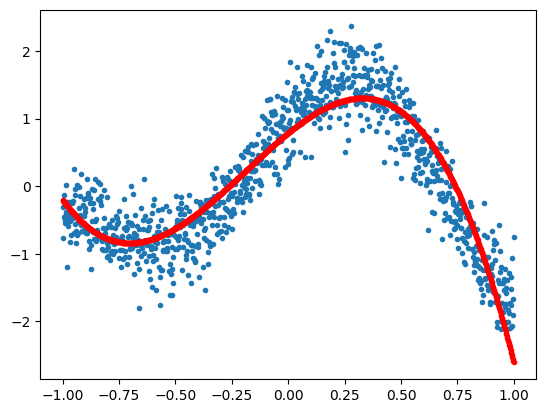

In [14]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.');

In [15]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'El coeficiente del término lineal del modelo es {model.coef_[0]:.3f}')
print(f'El coeficiente del término cuadrático del modelo es {model.coef_[1]:.3f}')
print(f'El coeficiente del término cúbico del modelo es {model.coef_[2]:.3f}')

El intercepto del modelo es 0.790
El coeficiente del término lineal del modelo es 2.705
El coeficiente del término cuadrático del modelo es -2.195
El coeficiente del término cúbico del modelo es -3.907


Pareciera que mientras más alto sea el grado del modelo, mejor predice. Se va a verificar con grados más altos de polinomios:

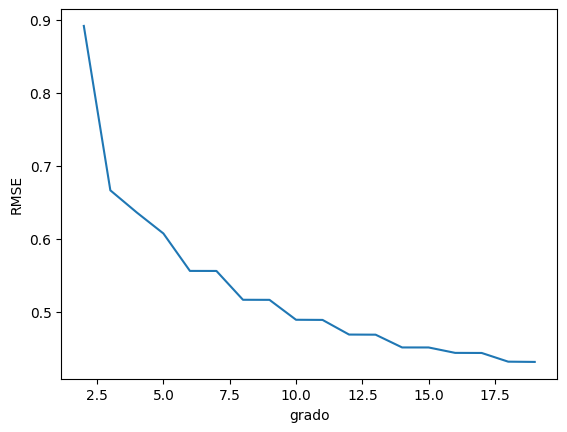

In [17]:
degrees = range(2,20)
scores_rmse = []
for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_p = poly.fit_transform(X)
  model.fit(X_p,y)
  scores_rmse.append(root_mean_squared_error(y, model.predict(X_p)))

fig = plt.figure()
plt.plot(degrees, scores_rmse, '-')
plt.xlabel('grado')
plt.ylabel('RMSE');

Se observa que después de cierto grado (5 o 6), el modelo mejora muy poco, así que aumentar la complejidad del modelo no garantiza que funcione mejor.

In [18]:
scores = pd.DataFrame({'grado': degrees, 'RMSE': scores_rmse})
scores.set_index('grado', inplace=True)
scores.sort_values(by='RMSE', ascending=True).head(10)

,RMSE
grado,
19,0.430929
18,0.431276
17,0.443207
16,0.443324
15,0.450748
14,0.450771
13,0.468278
12,0.468440
11,0.488515


En este caso el error se acerca asintóticamente a la desviación estándar del ruido, pero nunca va a ser menor a este.

R^2 del modelo: 0.856
RMSE del modelo: 0.377


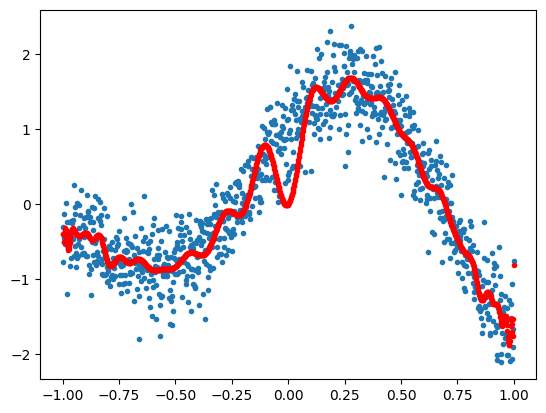

In [19]:
poly = PolynomialFeatures(degree=100, include_bias=False)
X_p = poly.fit_transform(X)
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.');

Por otra parte, los coeficientes se hacen más grandes a medida que aumenta  el grado del polinomio:

In [20]:
model.coef_

array([ 3.89857532e+00,  2.41282927e+02, -1.06523309e+02, -1.78815989e+04,
        7.78543014e+03,  5.97209356e+05, -2.37591030e+05, -1.11545114e+07,
        3.84205547e+06,  1.29519307e+08, -3.75797237e+07, -9.92381772e+08,
        2.37519240e+08,  5.17464587e+09, -9.98543629e+08, -1.84912949e+10,
        2.78234917e+09,  4.42868745e+10, -4.87372135e+09, -6.55801040e+10,
        4.39319042e+09,  4.39613632e+10,  1.98822442e+08,  1.99596249e+10,
       -3.65151301e+09, -4.30892304e+10,  3.24425688e+08, -1.31092311e+10,
        3.10806426e+09,  3.42256423e+10,  7.20942863e+08,  2.31689902e+10,
       -2.34427940e+09, -1.77578628e+10, -2.11522823e+09, -3.17555701e+10,
        4.88684202e+08, -8.51009476e+09,  2.31755817e+09,  2.09978812e+10,
        1.75442856e+09,  2.75100575e+10, -3.26698673e+08,  8.99937818e+09,
       -1.97662022e+09, -1.53770874e+10, -1.96359326e+09, -2.57898623e+10,
       -5.16512074e+08, -1.63981017e+10,  1.21004456e+09,  3.82949704e+09,
        2.04509003e+09,  

In [21]:
model.intercept_

0.0